In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Tracer import WindField, Trajectory
from Tracer.solvers import solver_rk45, solver_euler
from mpl_toolkits.mplot3d import Axes3D

### Simulator

In [ ]:
# Rans file
datafile = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z005m_2m_cartesian.nc'

# play field parameters - dont touch unless necessary
P0=np.array([-100, -100, 0])
nx = 500        # length of play field
ny = 200        # width of play field
nz = 100        # height of play field
dt = 0.01       # time step

# Basis shot parameters - if not otherwise specified, these are used
shot_speed = 76.44384   # intital velocity
shot_angle = 10.4       # initial angle for trajectory	
shot_spin = 2545        # initial spin

spin_axis = 0

def include_baseline(values, baseline, design_n=design_n):
    """
    Ensures baseline is included while keeping exactly n_total samples.
    Replaces the nearest sampled value if baseline is not already present.
    """
    values = np.array(values)

    # if baseline already exists, just return sorted values
    if np.isclose(values, baseline).any():
        return np.sort(values)

    # find nearest existing point and replace it
    idx = np.argmin(np.abs(values - baseline))
    values[idx] = baseline

    return np.sort(values)

# Basis wind parameters - if not otherwise specified, these are used
U_ref = 6      # reference wind speed at 10 meters above ground (6 m/s is approx. danish average)
z0 = 0.03       # surface roughness
direction = 0   # wind direction (0 is tailwind, 180 is headwind)

design_n = 10

baseline_values = {
    "shot_speed": shot_speed,
    "shot_angle": shot_angle,
    "shot_spin": shot_spin,
    "U_ref": U_ref,
    "z0": z0,
    "direction": direction
}

parameter_library = {
    "shot_speed": {
        "values": include_baseline(np.linspace(35, 85, design_n), shot_speed),
        "name": "Shot speed",
        "unit": "m/s"
    },
    "shot_angle": {
        "values": include_baseline(np.linspace(5, 25, design_n), shot_angle),
        "name": "Shot angle",
        "unit": "deg"
    },
    "shot_spin": {
        "values": include_baseline(np.linspace(2000, 10000, design_n), shot_spin),
        "name": "Shot spin",
        "unit": "rpm"
    },
    "U_ref": {
        "values": include_baseline(np.linspace(2, 10, design_n), U_ref),
        "name": "Wind speed",
        "unit": "m/s"
    },
    "z0": {
        "values": include_baseline(np.logspace(np.log10(0.001), np.log10(1), design_n), z0),
        "name": "Roughness",
        "unit": "m"
    },
    "direction": {
        "values": include_baseline(np.linspace(0, 180, design_n), direction),
        "name": "Wind direction",
        "unit": "deg"
    }
}

In [61]:
summary_rows = []

for key, info in parameter_library.items():
    vals = np.array(info["values"])

    summary_rows.append({
        "Key": key,
        "Parameter": info["name"],
        "Baseline": baseline_values[key],
        "Unit": info["unit"],
        "Min": np.min(vals),
        "Max": np.max(vals),
        "Samples": len(vals)
    })

parameter_summary = pd.DataFrame(summary_rows)
display(parameter_summary)

expanded_rows = []

for key, info in parameter_library.items():
    vals = list(np.round(info["values"], 4))

    row = {
        "Key": key,
        "Parameter": info["name"],
        "Baseline": baseline_values[key],
        "Unit": info["unit"]
    }

    for i, v in enumerate(vals, 1):
        row[f"Value {i}"] = v

    expanded_rows.append(row)

parameter_expanded = pd.DataFrame(expanded_rows)
display(parameter_expanded)

,Key,Parameter,Baseline,Unit,Min,Max,Samples
0,shot_speed,Shot speed,76.44384,m/s,35.000,85.0,10
1,shot_angle,Shot angle,10.40000,deg,5.000,25.0,10
2,shot_spin,Shot spin,2545.00000,rpm,2000.000,10000.0,10
3,U_ref,Wind speed,6.00000,m/s,2.000,10.0,10
4,z0,Roughness,0.03000,m,0.001,1.0,10
5,direction,Wind direction,0.00000,deg,0.000,180.0,10


,Key,Parameter,Baseline,Unit,Value 1,Value 2,Value 3,Value 4,Value 5,Value 6,Value 7,Value 8,Value 9,Value 10
0,shot_speed,Shot speed,76.44384,m/s,35.000,40.5556,46.1111,51.6667,57.2222,62.7778,68.3333,76.4438,79.4444,85.0
1,shot_angle,Shot angle,10.40000,deg,5.000,7.2222,10.4000,11.6667,13.8889,16.1111,18.3333,20.5556,22.7778,25.0
2,shot_spin,Shot spin,2545.00000,rpm,2000.000,2545.0000,3777.7778,4666.6667,5555.5556,6444.4444,7333.3333,8222.2222,9111.1111,10000.0
3,U_ref,Wind speed,6.00000,m/s,2.000,2.8889,3.7778,4.6667,6.0000,6.4444,7.3333,8.2222,9.1111,10.0
4,z0,Roughness,0.03000,m,0.001,0.0022,0.0046,0.0100,0.0300,0.0464,0.1000,0.2154,0.4642,1.0
5,direction,Wind direction,0.00000,deg,0.000,20.0000,40.0000,60.0000,80.0000,100.0000,120.0000,140.0000,160.0000,180.0


In [4]:
# ============================================================
# --- Simulation ---
# ============================================================


def run_simulation(shot_speed=shot_speed, shot_angle=shot_angle,
                   shot_spin=shot_spin, U_ref=U_ref,
                   z0=z0, direction=direction):

    # trajectory with rans wind
    log_wind = WindField(profile='rans', ds=datafile, U_ref=U_ref)
    log_trajectory = Trajectory(ball_speed=shot_speed, launch_angle=shot_angle, spin_rate=shot_spin, spin_axis=spin_axis,wind=log_wind)
    log_trajectory.solve(solver='euler', dt=dt)
    log_p = log_trajectory.p

    # trajectory with uniform wind
    uni_wind = WindField(direction=direction, profile='uniform', U_ref=U_ref)
    uni_trajectory = Trajectory(ball_speed=shot_speed, launch_angle=shot_angle, spin_rate=shot_spin, spin_axis=spin_axis,wind=uni_wind)
    uni_trajectory.solve(solver='euler',dt=dt)
    uni_p = uni_trajectory.p

    return log_p, uni_p

# ============================================================
# --- Baseline Detector ---
# ============================================================

def is_baseline(param_key, value, tol=1e-8):
    return np.isclose(value, baseline_values[param_key], atol=tol)

# ============================================================
# --- Universal Parameter Formatter ---
# ============================================================

def format_param(v):
    if v == 0:
        return "0"
    elif abs(v) < 1e-2:
        return f"{v:.2e}"
    elif abs(v) >= 1000:
        return f"{v:.0f}"
    elif abs(v) >= 1:
        return f"{v:.2f}".rstrip('0').rstrip('.')
    else:
        return f"{v:.4f}".rstrip('0').rstrip('.')


# ============================================================
# --- Error Models ---
# ============================================================

def percent_distance_error(log_p, uni_p):
    dx = uni_p[-1, 0] - log_p[-1, 0]
    dy = uni_p[-1, 1] - log_p[-1, 1]
    norm = np.sqrt((log_p[-1, 0]-log_p[0, 0])**2 + (log_p[-1, 1]-log_p[0, 1])**2)
    return np.sqrt(dx**2 + dy**2) / norm * 100

def distance_error(log_p, uni_p):
    dx = uni_p[-1, 0] - log_p[-1, 0]
    dy = uni_p[-1, 1] - log_p[-1, 1]
    return np.sqrt(dx**2 + dy**2)

def x_distance_error(log_p, uni_p):
    return uni_p[-1, 0] - log_p[-1, 0]

def y_distance_error(log_p, uni_p):
    return uni_p[-1, 1] - log_p[-1, 1]


# ============================================================
# --- Varying One Parameter ---
# ============================================================

def varying_parameter(param_key, shot_speed=shot_speed, shot_angle=shot_angle,
                      shot_spin=shot_spin, U_ref=U_ref,
                      z0=z0, direction=direction):

    p = parameter_library[param_key]
    param = p["values"]

    param_results = []
    param_errors = []
    param_abs_errors = []
    param_x_errors = []
    param_y_errors = []

    for value in param:

        kwargs = {
            "shot_speed": shot_speed,
            "shot_angle": shot_angle,
            "shot_spin": shot_spin,
            "U_ref": U_ref,
            "z0": z0,
            "direction": direction
        }

        kwargs[param_key] = value

        log_p, uni_p = run_simulation(**kwargs)

        param_results.append((log_p, uni_p))
        param_errors.append(percent_distance_error(log_p, uni_p))
        param_abs_errors.append(distance_error(log_p, uni_p))
        param_x_errors.append(x_distance_error(log_p, uni_p))
        param_y_errors.append(y_distance_error(log_p, uni_p))

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    ax1, ax2, ax3, ax4 = axes.flatten()
    colors = plt.cm.viridis(np.linspace(0, 1, len(param_results)))

    # --- 1. Trajectories ---
    for i, (log_p, uni_p) in enumerate(param_results):

        if is_baseline(param_key, param[i]):
            ax1.plot(log_p[:, 0], log_p[:, 2],
                     color='black', linewidth=3,
                     label=f"Baseline RANS ({format_param(param[i])} {p['unit']})")

            ax1.plot(uni_p[:, 0], uni_p[:, 2], '--',
                     color='black', linewidth=3,
                     label=f"Baseline Uni ({format_param(param[i])} {p['unit']})")
        else:
            ax1.plot(log_p[:, 0], log_p[:, 2],
                     color=colors[i],
                     label=f"RANS, {format_param(param[i])} {p['unit']}")

            ax1.plot(uni_p[:, 0], uni_p[:, 2], '--',
                     color=colors[i],
                     label=f"Uni, {format_param(param[i])} {p['unit']}")

    ax1.set_xlabel("Length (m)")
    ax1.set_ylabel("Height (m)")
    ax1.set_title(f"Trajectories with varying {p['name']}")
    ax1.legend(loc='center right', bbox_to_anchor=(-0.15, 0.5), fontsize=8)

    # --- 2. Percent Error ---
    ax2.plot(param, param_errors, color='gray')

    for i in range(len(param)):
        if is_baseline(param_key, param[i]):
            ax2.scatter(param[i], param_errors[i],
                        color='black', marker='x', s=120, linewidths=3,
                        zorder=5, label='Baseline')
        else:
            ax2.scatter(param[i], param_errors[i], color=colors[i])

    ax2.set_xlabel(f"{p['name']} ({p['unit']})")
    ax2.set_ylabel("Landing position deviation (%)")
    ax2.set_title(f"% Error vs {p['name']}")
    ax2.set_xticks(param)
    ax2.set_xticklabels([format_param(v) for v in param], rotation=30)
    ax2.grid()

    # --- 3. X vs Y Error ---
    for i in range(len(param)):
        if is_baseline(param_key, param[i]):
            ax3.scatter(param_y_errors[i], param_x_errors[i],
                        color='black', marker='x', s=120, linewidths=3,
                        label='Baseline')
        else:
            ax3.scatter(param_y_errors[i], param_x_errors[i],
                        color=colors[i],
                        label=f"{format_param(param[i])} {p['unit']}")

        ax3.text(param_y_errors[i], param_x_errors[i],
                 format_param(param[i]), fontsize=8)

    ax3.axhline(0, linestyle='--')
    ax3.axvline(0, linestyle='--')
    ax3.set_xlabel("Y error (m)")
    ax3.set_ylabel("X error (m)")
    ax3.set_title("Directional Error (Y vs X)")
    ax3.grid()

    # --- 4. Absolute Error ---
    ax4.plot(param, param_abs_errors, color='gray')

    for i in range(len(param)):
        if is_baseline(param_key, param[i]):
            ax4.scatter(param[i], param_abs_errors[i],
                        color='black', marker='x', s=120, linewidths=3,
                        zorder=5, label='Baseline')
        else:
            ax4.scatter(param[i], param_abs_errors[i], color=colors[i])

    ax4.set_xlabel(f"{p['name']} ({p['unit']})")
    ax4.set_ylabel("Landing position deviation (m)")
    ax4.set_title(f"Absolute Error vs {p['name']}")
    ax4.set_xticks(param)
    ax4.set_xticklabels([format_param(v) for v in param], rotation=30)
    ax4.grid()

    plt.tight_layout()
    plt.show()


# ============================================================
# --- Varying Two Parameters ---
# ============================================================

def varying_two_parameters(param1_key, param2_key,
                           shot_speed=shot_speed, shot_angle=shot_angle,
                           shot_spin=shot_spin, U_ref=U_ref,
                           z0=z0, direction=direction):

    p1 = parameter_library[param1_key]
    p2 = parameter_library[param2_key]

    param1 = p1["values"]
    param2 = p2["values"]

    error_grid_percent = []
    error_grid = []

    for val1 in param1:
        row_errors_percent = []
        row_errors = []

        for val2 in param2:

            kwargs = {
                "shot_speed": shot_speed,
                "shot_angle": shot_angle,
                "shot_spin": shot_spin,
                "U_ref": U_ref,
                "z0": z0,
                "direction": direction
            }

            kwargs[param1_key] = val1
            kwargs[param2_key] = val2

            log_p, uni_p = run_simulation(**kwargs)

            row_errors_percent.append(percent_distance_error(log_p, uni_p))
            row_errors.append(distance_error(log_p, uni_p))

        error_grid_percent.append(row_errors_percent)
        error_grid.append(row_errors)

    error_grid_percent = np.array(error_grid_percent)
    error_grid = np.array(error_grid)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # --- Heatmap ---
    im = ax1.imshow(error_grid_percent, origin='lower', aspect='auto', vmin=0, vmax=16)

    base1 = baseline_values[param1_key]
    base2 = baseline_values[param2_key]

    i_base = np.where(np.isclose(param1, base1))[0][0]
    j_base = np.where(np.isclose(param2, base2))[0][0]

    ax1.scatter(j_base, i_base,
                color='black', marker='x', s=200, linewidths=3,
                label='Baseline')

    cbar = plt.colorbar(im, ax=ax1)
    cbar.set_label("Landing position deviation (%)")

    ax1.set_xticks(range(len(param2)))
    ax1.set_yticks(range(len(param1)))
    ax1.set_xticklabels([format_param(v) for v in param2], rotation=30)
    ax1.set_yticklabels([format_param(v) for v in param1])

    ax1.set_xlabel(f"{p2['name']} ({p2['unit']})")
    ax1.set_ylabel(f"{p1['name']} ({p1['unit']})")
    ax1.set_title(f"{p1['name']} vs {p2['name']}")

    # --- 2D line plot ---
    colors = plt.cm.viridis(np.linspace(0, 1, len(param1)))

    for i, val1 in enumerate(param1):
        ax2.plot(param2, error_grid[i, :],
                 marker='o',
                 color=colors[i],
                 label=f"{p1['name']}={format_param(val1)} {p1['unit']}")

    ax2.scatter(param2[j_base], error_grid[i_base, j_base],
                color='black',
                marker='x',
                s=150,
                linewidths=3,
                zorder=5,
                label='Baseline')

    ax2.set_xlabel(f"{p2['name']} ({p2['unit']})")
    ax2.set_ylabel("Landing position deviation (m)")
    ax2.set_title(f"Error vs {p2['name']} (for varying {p1['name']})")
    ax2.set_xticks(param2)
    ax2.set_xticklabels([format_param(v) for v in param2], rotation=30)
    ax2.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
    ax2.grid()

    plt.tight_layout()
    plt.show()

In [ ]:
def single_plot(param_key, shot_speed=shot_speed, shot_angle=shot_angle,
                      shot_spin=shot_spin, U_ref=U_ref,
                      z0=z0, direction=direction):

    p = parameter_library[param_key]
    param = p["values"]

    param_results = []
    param_errors = []
    param_abs_errors = []
    param_x_errors = []
    param_y_errors = []

    for value in param:

        kwargs = {
            "shot_speed": shot_speed,
            "shot_angle": shot_angle,
            "shot_spin": shot_spin,
            "U_ref": U_ref,
            "z0": z0,
            "direction": direction
        }

        kwargs[param_key] = value

        log_p, uni_p = run_simulation(**kwargs)

        param_results.append((log_p, uni_p))
        param_errors.append(percent_distance_error(log_p, uni_p))
        param_abs_errors.append(distance_error(log_p, uni_p))
        param_x_errors.append(x_distance_error(log_p, uni_p))
        param_y_errors.append(y_distance_error(log_p, uni_p))

    plt.figure(figsize=(18, 6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(param_results)))
    # --- 1. Trajectories ---
    for i, (log_p, uni_p) in enumerate(param_results):

        if is_baseline(param_key, param[i]):
            plt.plot(log_p[:, 0], log_p[:, 2],
                     color=colors[i], linewidth=3,
                     label=f"Baseline RANS ({format_param(param[i])} {p['unit']})")

            plt.plot(uni_p[:, 0], uni_p[:, 2], '--',
                     color='teal', linewidth=3,
                     label=f"Baseline Uni ({format_param(param[i])} {p['unit']})")

    plt.xlabel("Length (m)")
    plt.ylabel("Height (m)")
    plt.grid()
    plt.title(f"Trajectories with varying {p['name']}")
    plt.legend(fontsize=8)
    plt.show()

In [ ]:
def single_param_variation_plot(param_key, shot_speed=shot_speed, shot_angle=shot_angle,
                      shot_spin=shot_spin, U_ref=U_ref,
                      z0=z0, direction=direction):

    p = parameter_library[param_key]
    param = p["values"]

    param_results = []
    param_errors = []
    param_abs_errors = []
    param_x_errors = []
    param_y_errors = []

    for value in param:

        kwargs = {
            "shot_speed": shot_speed,
            "shot_angle": shot_angle,
            "shot_spin": shot_spin,
            "U_ref": U_ref,
            "z0": z0,
            "direction": direction
        }

        kwargs[param_key] = value

        log_p, uni_p = run_simulation(**kwargs)

        param_results.append((log_p, uni_p))
        param_errors.append(percent_distance_error(log_p, uni_p))
        param_abs_errors.append(distance_error(log_p, uni_p))
        param_x_errors.append(x_distance_error(log_p, uni_p))
        param_y_errors.append(y_distance_error(log_p, uni_p))

    plt.figure(figsize=(18, 6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(param_results)))
    # --- 1. Trajectories ---
    for i, (log_p, uni_p) in enumerate(param_results):

        if is_baseline(param_key, param[i]):
            plt.plot(log_p[:, 0], log_p[:, 2],
                     color=colors[i], linewidth=3,
                     label=f"RANS {format_param(param[i])} {p['unit']}")
        else:
            plt.plot(log_p[:, 0], log_p[:, 2],
                     color=colors[i],
                     label=f"RANS, {format_param(param[i])} {p['unit']}", linestyle='--')

    plt.xlabel("Length (m)")
    plt.ylabel("Height (m)")
    plt.grid()
    plt.title(f"Trajectories with varying {p['name']}")
    plt.legend(fontsize=8)
    plt.show()

In [ ]:
def single_plot_3D(param_key, shot_speed=shot_speed, shot_angle=shot_angle,
                   shot_spin=shot_spin, U_ref=U_ref,
                   z0=z0, direction=direction):

    p = parameter_library[param_key]
    param = p["values"]

    param_results = []
    param_errors = []
    param_abs_errors = []
    param_x_errors = []
    param_y_errors = []

    for value in param:

        kwargs = {
            "shot_speed": shot_speed,
            "shot_angle": shot_angle,
            "shot_spin": shot_spin,
            "U_ref": U_ref,
            "z0": z0,
            "direction": direction
        }

        kwargs[param_key] = value

        log_p, uni_p = run_simulation(**kwargs)

        param_results.append((log_p, uni_p))
        param_errors.append(percent_distance_error(log_p, uni_p))
        param_abs_errors.append(distance_error(log_p, uni_p))
        param_x_errors.append(x_distance_error(log_p, uni_p))
        param_y_errors.append(y_distance_error(log_p, uni_p))

    # ===============================
    # Create 3D Figure
    # ===============================
    fig = plt.figure(figsize=(20, 8))
    ax = fig.add_subplot(111, projection='3d')

    colors = plt.cm.viridis(np.linspace(0, 1, len(param_results)))

    for i, (log_p, uni_p) in enumerate(param_results):

        if is_baseline(param_key, param[i]):
            # ----- RANS trajectory -----
            ax.plot(log_p[:, 0], log_p[:, 1], log_p[:, 2],
                    color=colors[i], linewidth=3,
                    label=f"Baseline RANS ({format_param(param[i])} {p['unit']})")

            # ----- Uniform trajectory -----
            ax.plot(uni_p[:, 0], uni_p[:, 1], uni_p[:, 2],
                    '--', color='teal', linewidth=3,
                    label=f"Baseline Uni ({format_param(param[i])} {p['unit']})")

        #else:
            # Optional: show all varied cases in lighter colors
            #ax.plot(log_p[:, 0], log_p[:, 1], log_p[:, 2],
            #        color=colors[i], alpha=0.7)

            #ax.plot(uni_p[:, 0], uni_p[:, 1], uni_p[:, 2],
            #        '--', color=colors[i], alpha=0.5)

    # ===============================
    # Labels and styling
    # ===============================
    ax.set_xlabel("Length X (m)")
    ax.set_ylabel("Lateral Y (m)")
    ax.set_zlabel("Height Z (m)")

    ax.set_title(f"3D Trajectories with varying {p['name']}")
    ax.legend(fontsize=8)

    # Better viewing angle
    ax.view_init(elev=20, azim=45)

    ax.set_xlim(-10,270)
    ax.set_ylim(-20,20)
    ax.set_zlim(0, 60)

        # ---- Start point ----
    ax.scatter(log_p[0,0], log_p[0,1], log_p[0,2],
            s=50, marker='o', color='black')
    

    plt.tight_layout()
    plt.show()

In [38]:
def single_param_maxheight_carry(param_key, shot_speed=shot_speed, shot_angle=shot_angle,
                                shot_spin=shot_spin, U_ref=U_ref,
                                z0=z0, direction=direction):

    p = parameter_library[param_key]
    param = p["values"]

    param_results = []

    carry_list = []
    maxheight_list = []

    for value in param:

        kwargs = {
            "shot_speed": shot_speed,
            "shot_angle": shot_angle,
            "shot_spin": shot_spin,
            "U_ref": U_ref,
            "z0": z0,
            "direction": direction
        }

        kwargs[param_key] = value

        log_p, uni_p = run_simulation(**kwargs)

        param_results.append((log_p, uni_p))

        # --- Store metrics ---
        carry_list.append(log_p[:, 0].max())
        maxheight_list.append(log_p[:, 2].max())

    # =====================================
    # Create figure AFTER simulation loop
    # =====================================
    fig, axes = plt.subplots(1, 2,figsize=(14, 6),gridspec_kw={'width_ratios': [2, 1]})  # left is twice as wide
    ax1, ax2 = axes

    colors = plt.cm.viridis(np.linspace(0, 1, len(param_results)))

    # =====================================
    # LEFT: Trajectories
    # =====================================
    for i, (log_p, _) in enumerate(param_results):

        if is_baseline(param_key, param[i]):
            ax1.plot(log_p[:, 0], log_p[:, 2],
                     color='black', linewidth=3,
                     label=f"B, {format_param(param[i])} {p['unit']}")
        else:
            ax1.plot(log_p[:, 0], log_p[:, 2],
                     color=colors[i],
                     label=f"{format_param(param[i])} {p['unit']}",linestyle='--')

    ax1.set_xlabel("Length (m)")
    ax1.set_ylabel("Height (m)")
    ax1.set_title(f"Trajectories varying {p['name']}")
    ax1.grid()
    ax1.legend(fontsize=8)

    # =====================================
    # RIGHT: Carry vs Max Height
    # =====================================
    for i in range(len(param)):

        if is_baseline(param_key, param[i]):
            ax2.scatter(carry_list[i], maxheight_list[i],
                        color='black', marker='x', s=120, linewidths=3,
                        label='B')
        else:
            ax2.scatter(carry_list[i], maxheight_list[i],
                        color=colors[i])

        # label each point
        ax2.text(carry_list[i], maxheight_list[i],
                 format_param(param[i]), fontsize=8)

    ax2.set_xlabel("Carry Distance (m)")
    ax2.set_ylabel("Max Height (m)")
    ax2.set_title("Carry vs Max Height")
    ax2.grid()

    plt.tight_layout()
    plt.show()

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind fi

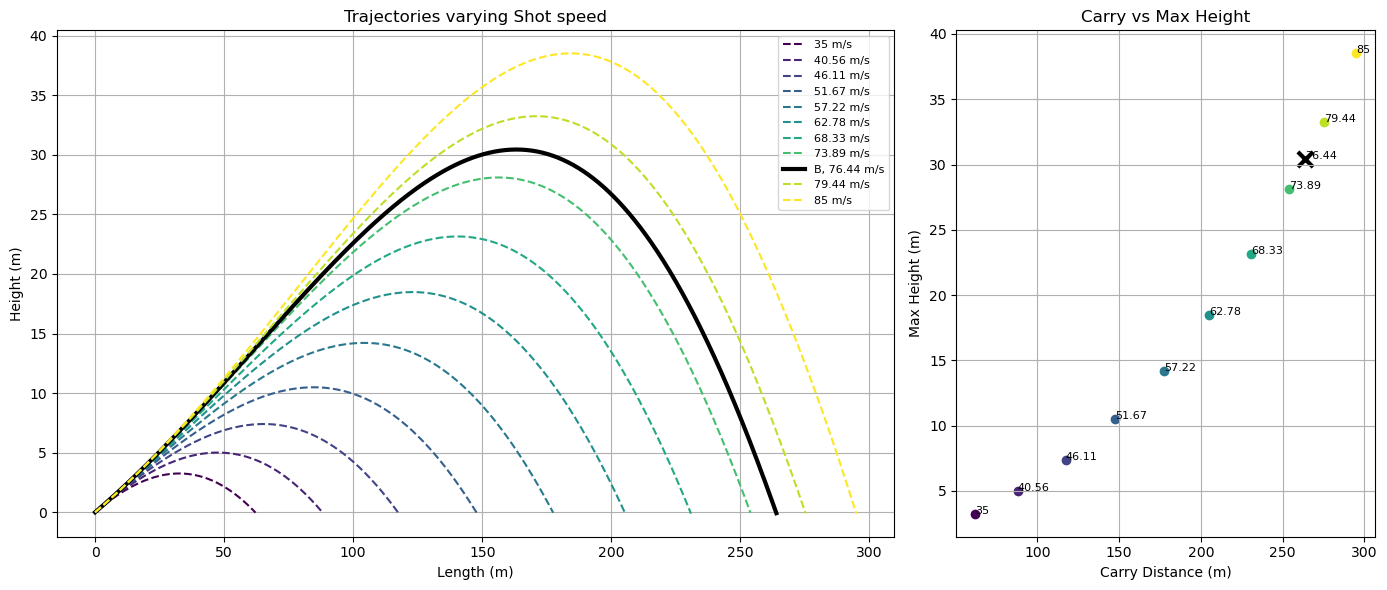

In [39]:
single_param_maxheight_carry('shot_speed')

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind fi

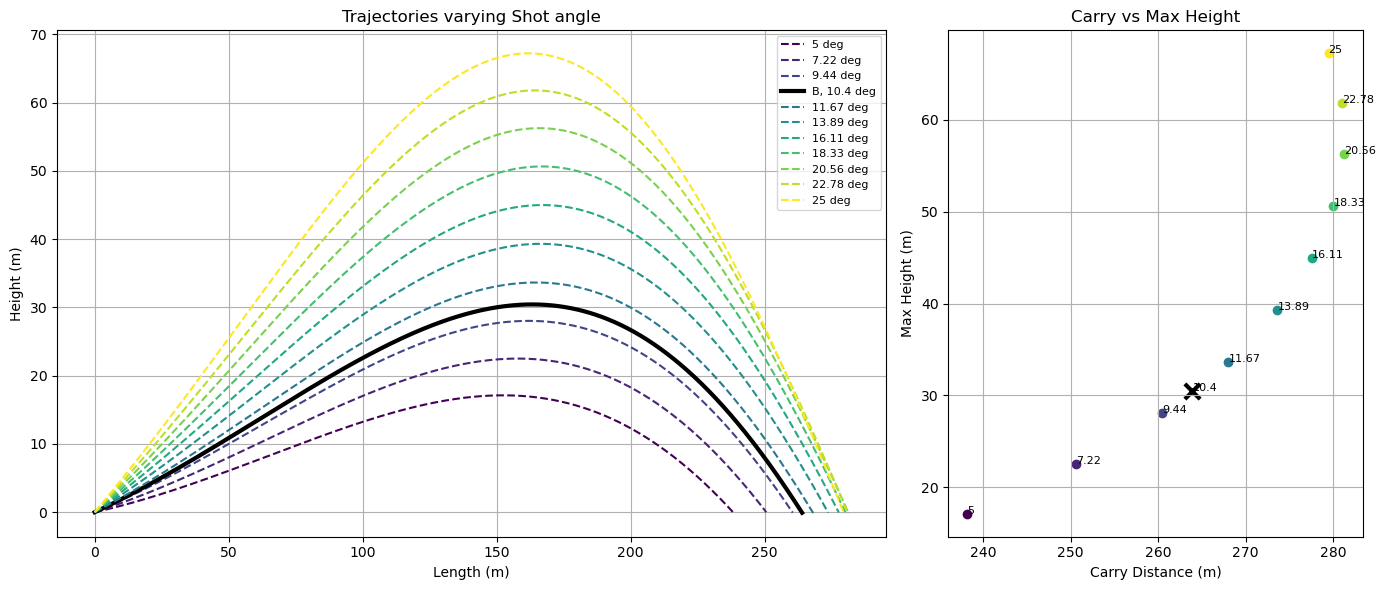

In [32]:
single_param_maxheight_carry('shot_angle')

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind fi

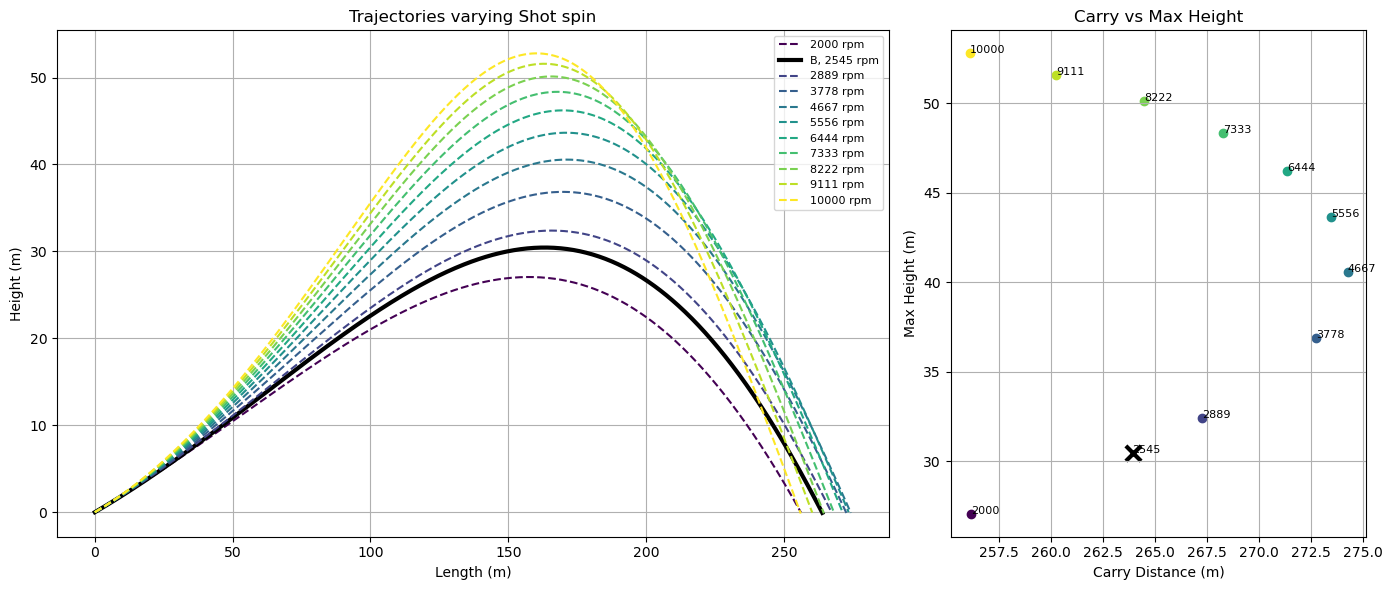

In [33]:
single_param_maxheight_carry('shot_spin')

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=2.0, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=2.888888888888889, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=3.7777777777777777, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=4.666666666666666, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=5.555555555555555, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6.0, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6.444444444444445, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=7.333333333333333, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=8.222222222222221, z0=0.03, z_ref=10.0
S

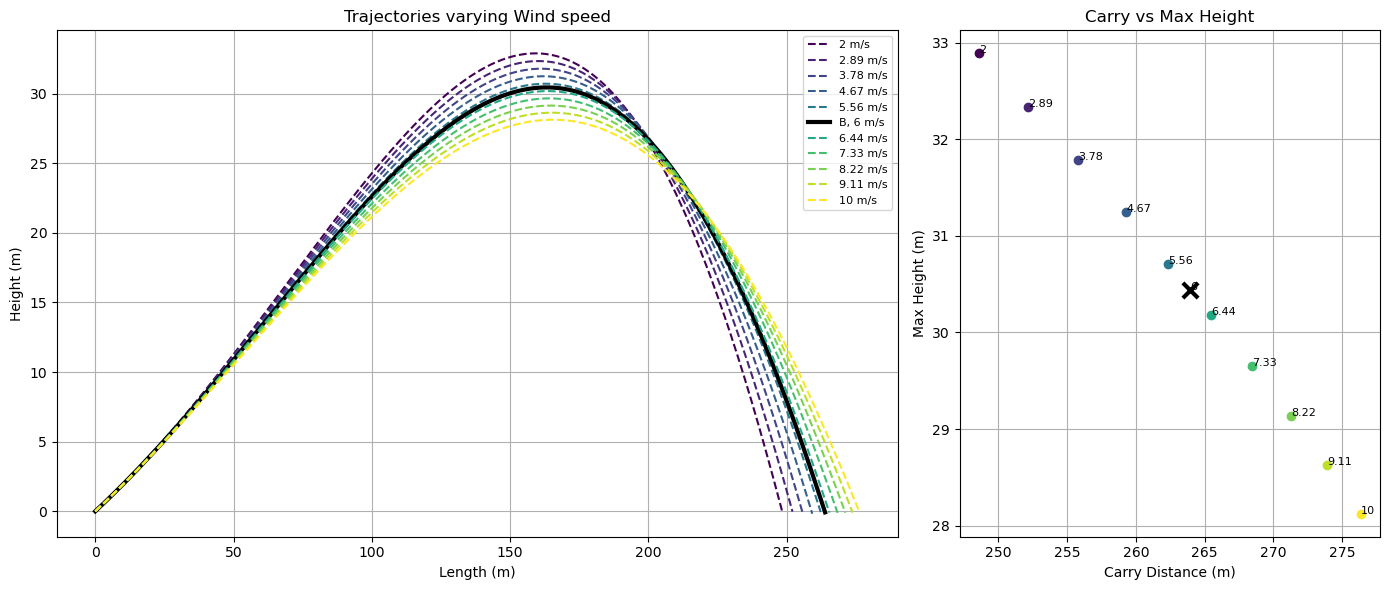

In [34]:
single_param_maxheight_carry('U_ref')